**Starting EDA**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For nicer plots
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
%matplotlib inline

In [2]:
# Path to cleaned CSV
file_path = "../data/processed_and_cleaned/child_malnutrition_cleaned.csv"

df = pd.read_csv(file_path)

# Quick look
print(df.head())
df.info()
df.describe()


  ISO_code Country_and_areas  Year                      SDG_Region  \
0      AFG       AFGHANISTAN  1997  Central Asia and Southern Asia   
1      AFG       AFGHANISTAN  2004  Central Asia and Southern Asia   
2      AFG       AFGHANISTAN  2013  Central Asia and Southern Asia   
3      AFG       AFGHANISTAN  2018  Central Asia and Southern Asia   
4      AGO            ANGOLA  1996              Sub-Saharan Africa   

  UNICEF_Region WHO_Region  Wasting  Stunting  Overweight  Underweight  \
0            SA       EMRO     18.2      53.2         6.5         44.9   
1            SA       EMRO      8.6      59.3         4.6         32.9   
2            SA       EMRO      9.5      40.4         5.3         24.6   
3            SA       EMRO      5.1      38.2         4.1         19.1   
4           SSA       AFRO      7.7      61.1         1.7         36.2   

   U5_Population_000s  
0         3838.876953  
1         4789.353027  
2         5444.572754  
3         5601.442871  
4         2749

,Year,Wasting,Stunting,Overweight,Underweight,U5_Population_000s
count,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,2004.734203,6.694935,28.244534,5.995838,15.471815,6040.296093
std,9.188923,4.830150,15.608023,4.245101,12.317963,16429.090828
min,1983.000000,0.000000,0.000000,0.000000,0.000000,7.816000
25%,1997.000000,2.900000,15.800000,3.000000,4.800000,573.083984
50%,2006.000000,5.650000,28.100000,5.250000,13.200000,1842.648010
75%,2012.000000,9.300000,39.000000,7.900000,22.600000,4007.509033
max,2020.000000,25.300000,73.600000,30.100000,66.800000,132966.781250


Univariate Analysis


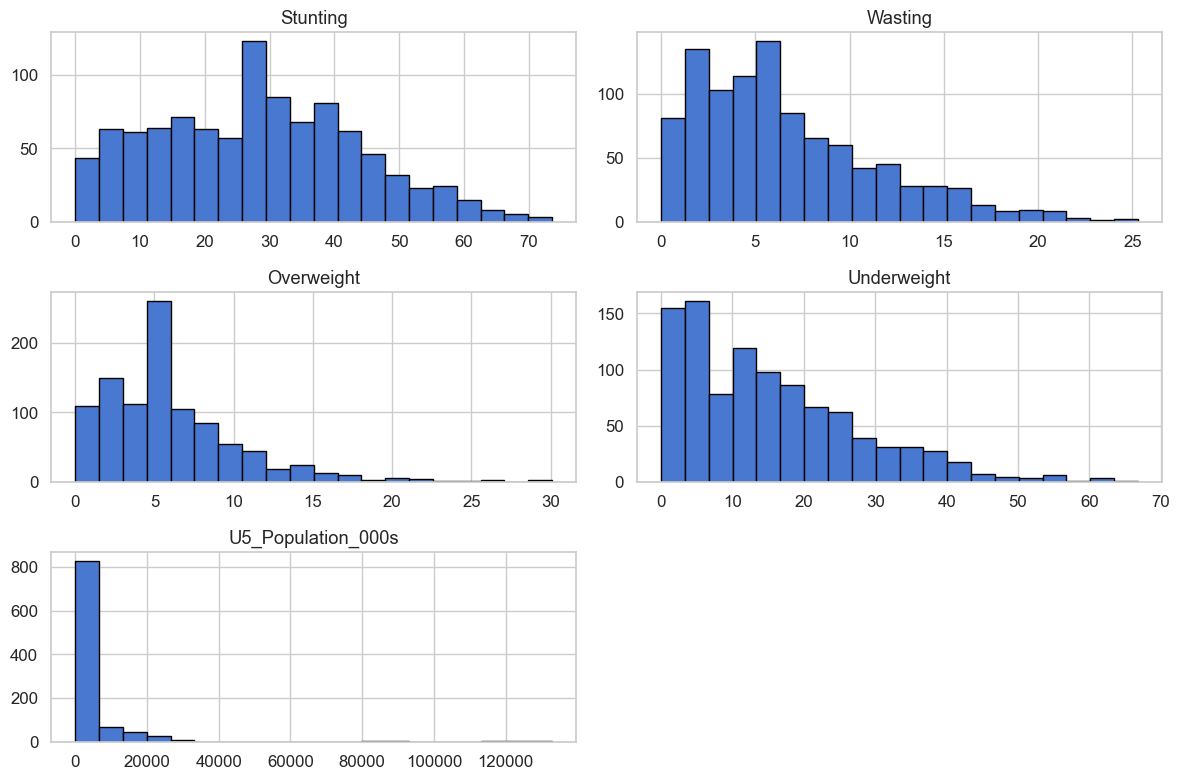

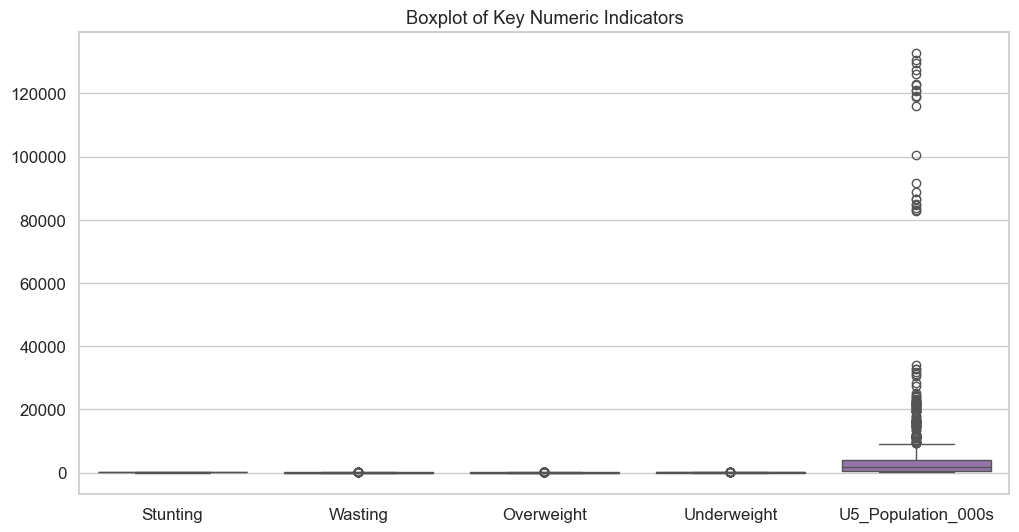

In [3]:
numeric_cols = ['Stunting', 'Wasting', 'Overweight', 'Underweight', 'U5_Population_000s']

# Histograms
df[numeric_cols].hist(figsize=(12,8), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

# Boxplots for outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Key Numeric Indicators")
plt.show()


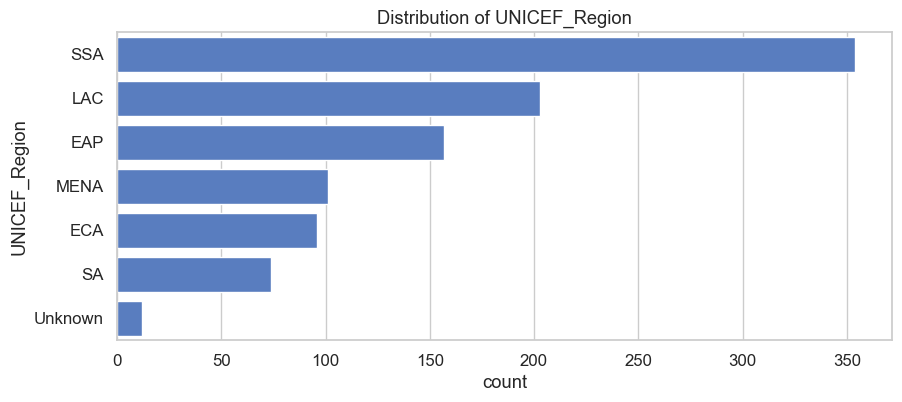

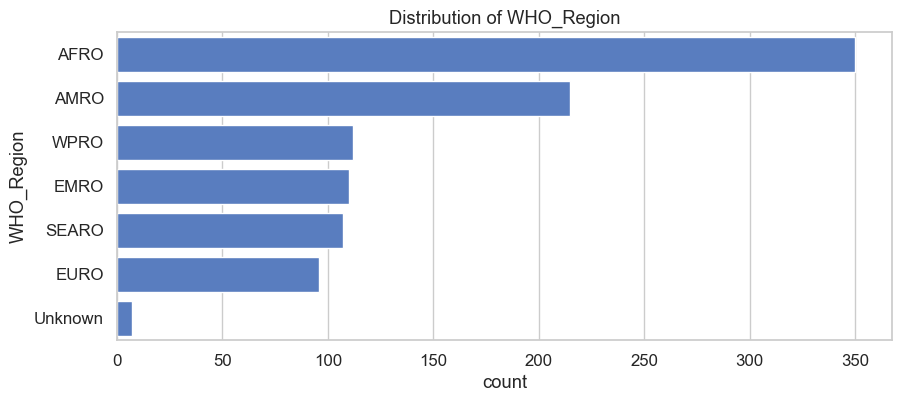

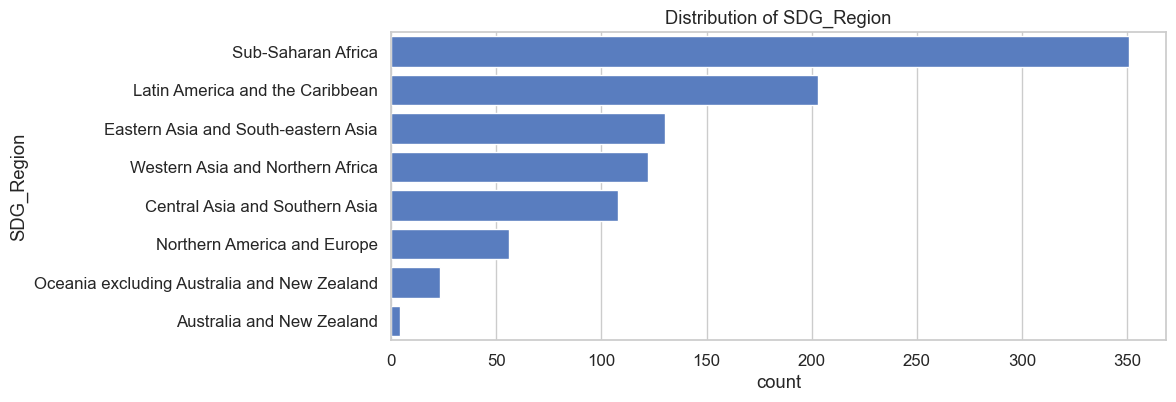

In [4]:
categorical_cols = ['UNICEF_Region', 'WHO_Region', 'SDG_Region']

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


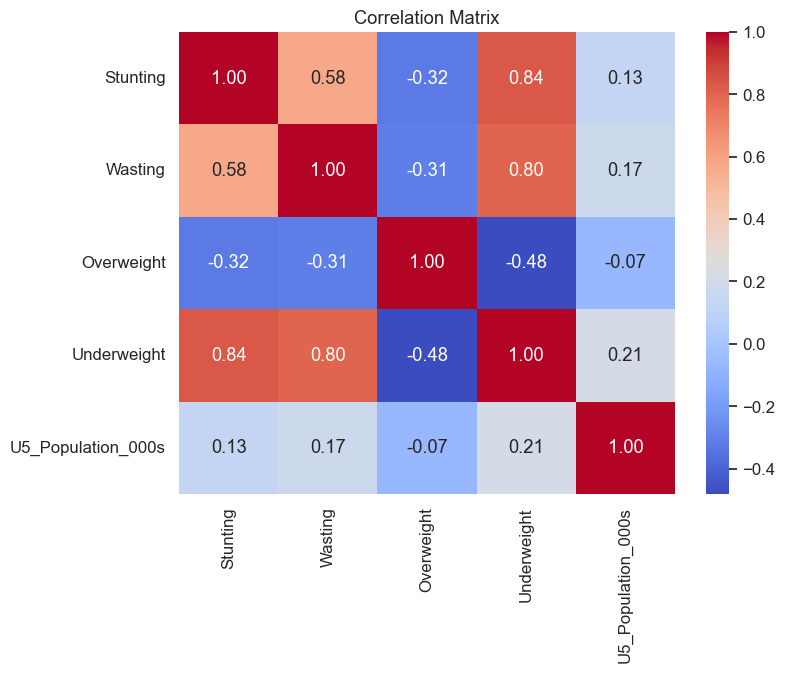

In [5]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


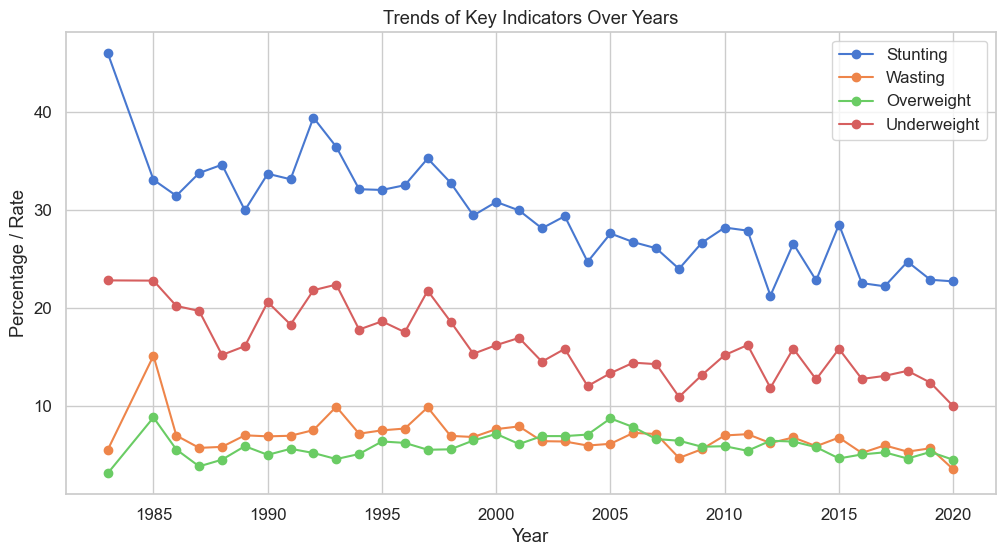

In [6]:
# Group by Year and calculate mean
yearly_trends = df.groupby('Year')[numeric_cols[:-1]].mean()  # Exclude U5_Population

plt.figure(figsize=(12,6))
for col in yearly_trends.columns:
    plt.plot(yearly_trends.index, yearly_trends[col], marker='o', label=col)

plt.title("Trends of Key Indicators Over Years")
plt.xlabel("Year")
plt.ylabel("Percentage / Rate")
plt.legend()
plt.show()


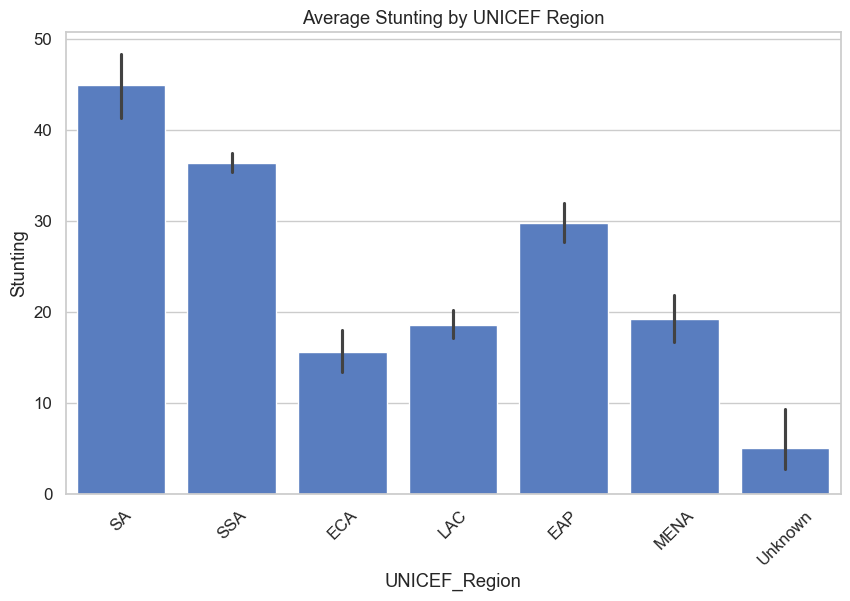

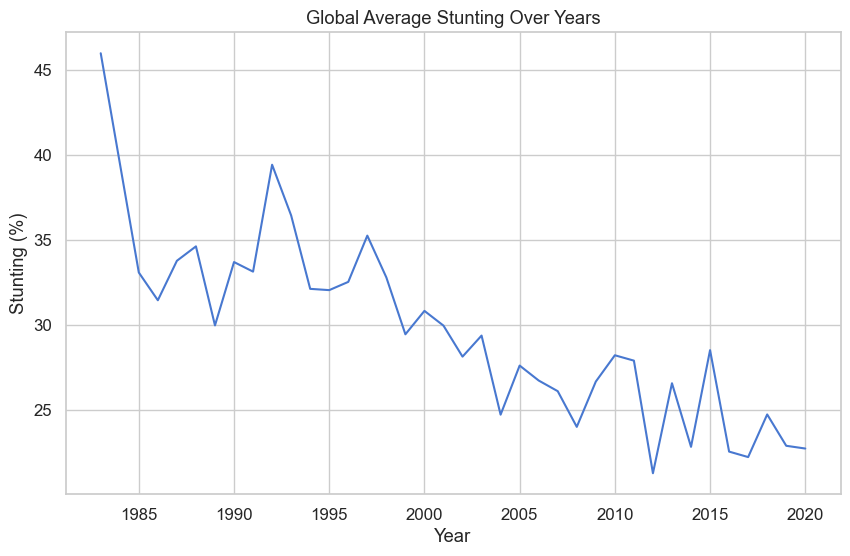

In [7]:
# Stunting by Region
plt.figure(figsize=(10,6))
sns.barplot(x='UNICEF_Region', y='Stunting', data=df)
plt.xticks(rotation=45)
plt.title("Average Stunting by UNICEF Region")
plt.show()

# Trend over years
plt.figure(figsize=(10,6))
df.groupby('Year')['Stunting'].mean().plot()
plt.title("Global Average Stunting Over Years")
plt.xlabel("Year")
plt.ylabel("Stunting (%)")
plt.show()



# Insights from the Child Malnutrition Dataset

## 1. Overall Trends
- Stunting, wasting, and overweight indicators vary significantly across countries and regions.
- Stunting is highest in Sub-Saharan Africa and South Asia, consistent with global malnutrition patterns.
- Wasting shows fluctuations by year, highlighting acute malnutrition episodes in specific regions.

## 2. Population Considerations
- Countries with larger under-5 populations contribute disproportionately to global malnutrition counts.
- Adjusting for population helps reveal relative risk rather than absolute numbers.

## 3. Regional Disparities
- UNICEF and WHO regions show systematic differences:
  - Southern Asia and Sub-Saharan Africa have higher stunting proportions.
  - Overweight prevalence is increasing in some regions, signaling the emerging double-burden of malnutrition.

## 4. Time Series Observations
- From 2000–2020, stunting and underweight rates generally decline, reflecting global progress.
- Overweight prevalence shows a gradual increase in multiple regions, indicating nutrition transitions.

## 5. Data Quality & Limitations
- Missing values exist in key columns such as `UNICEF_Region` and `U5_Population_000s`.
- Survey coverage differs across countries and years, potentially introducing bias.
- Estimates from different sources (MICS, NNS, Other) may not be fully comparable.

## 6. Key Takeaways for Modeling
- **Target variables:** `Stunting`, `Wasting`, or `Overweight` depending on focus.
- **Potential predictors:** Year, Region, Population, Survey type.
- Observed correlations suggest that region and population size are strong predictors of malnutrition indicators.

## 7. Relevance to SDGs
- Analysis aligns with **SDG 2: Zero Hunger**, highlighting countries lagging in child nutrition targets.
- Regional trends provide actionable insights for policy-making and targeted interventions.